#Task 2: Exploratory Data Analysis (EDA) & Data Preprocessing on Healthcare Dataset

Importing Libraries : Pandas is used for data manipulation,NumPy for numerical operations, Matplotlib
and Seaborn for data visualization.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Uploaded the healthcare dataset (healthcare_data.csv) from the computer storage to google colab

In [4]:
from google.colab import files

uploaded = files.upload()

Saving healthcare_data_100_records.csv to healthcare_data_100_records.csv


#**1. Data Cleaning**

Read the uploaded CSV file into a Pandas DataFrame for analysis

In [5]:
df = pd.read_csv("healthcare_data_100_records.csv")

Display rows of the dataset to verify that the data has been loaded correctly using df

In [6]:
df

,Patient_ID,Patient_Name,Age,Gender,Blood_Pressure,Heart_Rate,BMI,Diabetes,Smoking_Status,Hospital_Visits,Medical_Cost
0,P001,Vihaan Sharma,65,Female,131.0,74.0,20.8,Yes,Smoker,9.0,115604.0
1,P002,Vivaan Sharma,23,Male,129.0,92.0,30.0,Yes,Non-Smoker,3.0,122757.0
2,P003,Karan Singh,69,Male,120.0,104.0,26.5,No,Smoker,3.0,93236.0
3,P004,Vihaan Verma,42,Male,145.0,82.0,30.1,Yes,Non-Smoker,8.0,37722.0
4,P005,Sneha Verma,53,Female,146.0,96.0,21.8,Yes,Smoker,10.0,64742.0
...,...,...,...,...,...,...,...,...,...,...,...
95,P011,Aditya Sharma,73,Male,119.0,100.0,21.2,No,Smoker,6.0,105039.0
96,P025,Diya Kulkarni,36,Female,162.0,69.0,21.8,Yes,Smoker,NaN,147133.0
97,P040,Diya Patel,55,Female,104.0,NaN,29.9,No,Non-Smoker,6.0,139066.0
98,P099,Karan Singh,62,Female,102.0,102.0,25.9,Yes,Smoker,9.0,135214.0


Display the dataset information, including the number of rows, columns, data types, and missing values

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Patient_ID       100 non-null    object 
 1   Patient_Name     100 non-null    object 
 2   Age              100 non-null    int64  
 3   Gender           100 non-null    object 
 4   Blood_Pressure   99 non-null     float64
 5   Heart_Rate       98 non-null     float64
 6   BMI              99 non-null     float64
 7   Diabetes         100 non-null    object 
 8   Smoking_Status   100 non-null    object 
 9   Hospital_Visits  98 non-null     float64
 10  Medical_Cost     99 non-null     float64
dtypes: float64(5), int64(1), object(5)
memory usage: 8.7+ KB


Checks the total number of rows and columns present in the dataset

In [8]:
df.shape

(100, 11)

Displays the column names

In [9]:
df.columns

Index(['Patient_ID', 'Patient_Name', 'Age', 'Gender', 'Blood_Pressure',
       'Heart_Rate', 'BMI', 'Diabetes', 'Smoking_Status', 'Hospital_Visits',
       'Medical_Cost'],
      dtype='object')

Identify the number of missing values present in each column

In [10]:
df.isnull().sum()

,0
Patient_ID,0
Patient_Name,0
Age,0
Gender,0
Blood_Pressure,1
Heart_Rate,2
BMI,1
Diabetes,0
Smoking_Status,0
Hospital_Visits,2


Replace missing values in numerical columns with their respective column mean

In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)

Verified that all missing values have been handled successfully

In [12]:
df.isnull().sum()

,0
Patient_ID,0
Patient_Name,0
Age,0
Gender,0
Blood_Pressure,0
Heart_Rate,0
BMI,0
Diabetes,0
Smoking_Status,0
Hospital_Visits,0


Counted the number of duplicate records present in the dataset

In [13]:
df.duplicated().sum()

np.int64(3)

Removed duplicate records to improve data quality

In [14]:
df.drop_duplicates(inplace=True)

Counted the number after removing the duplicate records present in the dataset

In [15]:
df.duplicated().sum()

np.int64(0)

#**2. Data Preprocessing**

**Encode Categorical Features** : Convert categorical (text) data into numerical values so it can be used for data analysis and Machine Learning models.


1) ENCODE GENDER

Convert the categorical values in the Gender column into numerical values (Male = 0, Female = 1)

In [16]:
df["Gender"] = df["Gender"].map({
    "Male":0,
    "Female":1
})

2. ENCODE DIABETES

Convert the Diabetes column into numerical values (No = 0, Yes = 1)

In [17]:
df["Diabetes"] = df["Diabetes"].map({
    "No":0,
    "Yes":1
})

3. ENCODE SMOKING STATUS

Convert the Smoking_Status column into numerical values (Non-Smoker = 0, Smoker = 1).

In [18]:
df["Smoking_Status"] = df["Smoking_Status"].map({
    "Non-Smoker":0,
    "Smoker":1
})

Displayed the updated dataset again to verify that all categorical values have been successfully encoded

In [19]:
df

,Patient_ID,Patient_Name,Age,Gender,Blood_Pressure,Heart_Rate,BMI,Diabetes,Smoking_Status,Hospital_Visits,Medical_Cost
0,P001,Vihaan Sharma,65,1,131.0,74.0,20.8,1,1,9.0,115604.0
1,P002,Vivaan Sharma,23,0,129.0,92.0,30.0,1,0,3.0,122757.0
2,P003,Karan Singh,69,0,120.0,104.0,26.5,0,1,3.0,93236.0
3,P004,Vihaan Verma,42,0,145.0,82.0,30.1,1,0,8.0,37722.0
4,P005,Sneha Verma,53,1,146.0,96.0,21.8,1,1,10.0,64742.0
...,...,...,...,...,...,...,...,...,...,...,...
92,P093,Sneha Mehta,58,1,169.0,62.0,30.3,1,0,3.0,28692.0
93,P094,Kavya Verma,66,0,156.0,70.0,31.9,1,1,5.0,19711.0
94,P095,Ishita Mehta,41,1,118.0,75.0,28.6,1,1,2.0,25701.0
98,P099,Karan Singh,62,1,102.0,102.0,25.9,1,1,9.0,135214.0


#**3. Descriptive Statistics**

Generated summary statistics such as count, mean, standard deviation, minimum, maximum for numerical columns

In [20]:
df.describe()

,Age,Gender,Blood_Pressure,Heart_Rate,BMI,Diabetes,Smoking_Status,Hospital_Visits,Medical_Cost
count,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,51.969072,0.505155,134.393939,83.573112,28.631980,0.505155,0.536082,5.416789,81366.212434
std,16.623561,0.502571,19.288649,14.791428,5.689931,0.502571,0.501287,3.659083,42014.200427
min,18.000000,0.000000,102.000000,60.000000,18.100000,0.000000,0.000000,0.000000,10105.000000
25%,39.000000,0.000000,118.000000,71.000000,23.500000,0.000000,0.000000,3.000000,38094.000000
50%,55.000000,1.000000,134.000000,83.591837,28.700000,1.000000,1.000000,5.000000,82132.000000
75%,66.000000,1.000000,151.000000,96.000000,33.300000,1.000000,1.000000,8.000000,117358.000000
max,78.000000,1.000000,170.000000,110.000000,38.000000,1.000000,1.000000,12.000000,149841.000000


#**4. Correlation Analysis**

: It means finding the relationship betweem two variables (Correlation values range from -1(Perfect negative correlation) to +1(Perfect positive correlation))

Correlation Matrix : It is simply a table that shows the correlation between every pair of numeric columns

In [21]:
df.corr(numeric_only=True)

,Age,Gender,Blood_Pressure,Heart_Rate,BMI,Diabetes,Smoking_Status,Hospital_Visits,Medical_Cost
Age,1.000000,0.023086,-0.289575,0.080936,-0.010297,0.029320,0.139513,0.111894,0.030428
Gender,0.023086,1.000000,-0.094659,0.044153,-0.050870,0.092687,0.071611,-0.073605,-0.008434
Blood_Pressure,-0.289575,-0.094659,1.000000,-0.068785,0.065806,0.083490,-0.009990,-0.038076,-0.081328
Heart_Rate,0.080936,0.044153,-0.068785,1.000000,-0.037920,-0.215911,0.025566,-0.004345,0.093441
BMI,-0.010297,-0.050870,0.065806,-0.037920,1.000000,-0.024643,-0.190128,-0.240805,-0.097700
Diabetes,0.029320,0.092687,0.083490,-0.215911,-0.024643,1.000000,-0.011083,0.056678,-0.126552
Smoking_Status,0.139513,0.071611,-0.009990,0.025566,-0.190128,-0.011083,1.000000,0.106512,-0.038864
Hospital_Visits,0.111894,-0.073605,-0.038076,-0.004345,-0.240805,0.056678,0.106512,1.000000,0.076966
Medical_Cost,0.030428,-0.008434,-0.081328,0.093441,-0.097700,-0.126552,-0.038864,0.076966,1.000000


Correlation Heatmap

Visualize the correlation matrix using a heatmap for easier interpretation of relationships between variables.
It is a coloured visual representation of the Correlation Matrix

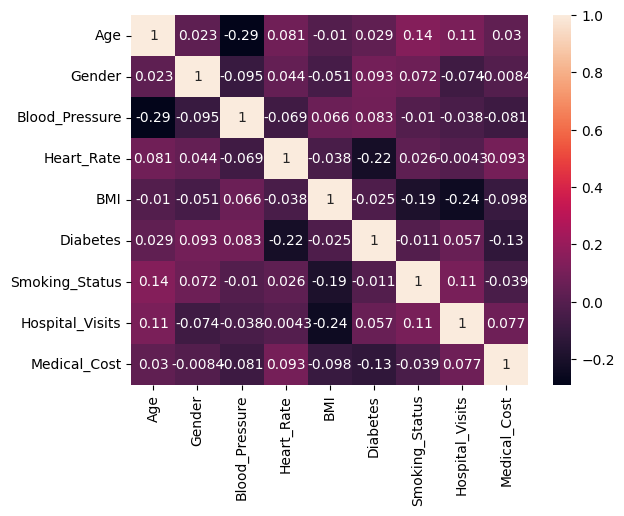

In [22]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)
plt.show()

#**5. Generate Business Insights**

Objective :
This section summarizes the key findings from the Exploratory Data Analysis (EDA) using summary statistics and visualizations. The generated insights help understand the dataset, identify patterns and trends, and prepare the data for Machine Learning and AI applications.

        HEALTHCARE DATASET - BUSINESS INSIGHTS REPORT

📊 SUMMARY STATISTICS
---------------------------------------------------------------------------

Overall Dataset Summary
---------------------------------------------------------------------------


👥 Total Patients            : 97
👨 Male Patients             : 48
👩 Female Patients           : 49
🩺 Patients with Diabetes    : 49
💚 Patients without Diabetes : 48
🚬 Smokers                  : 52
🚭 Non-Smokers              : 45
📅 Average Hospital Visits   : 5.42
📈 Average BMI               : 28.63
💰 Average Medical Cost      : ₹81,366.21




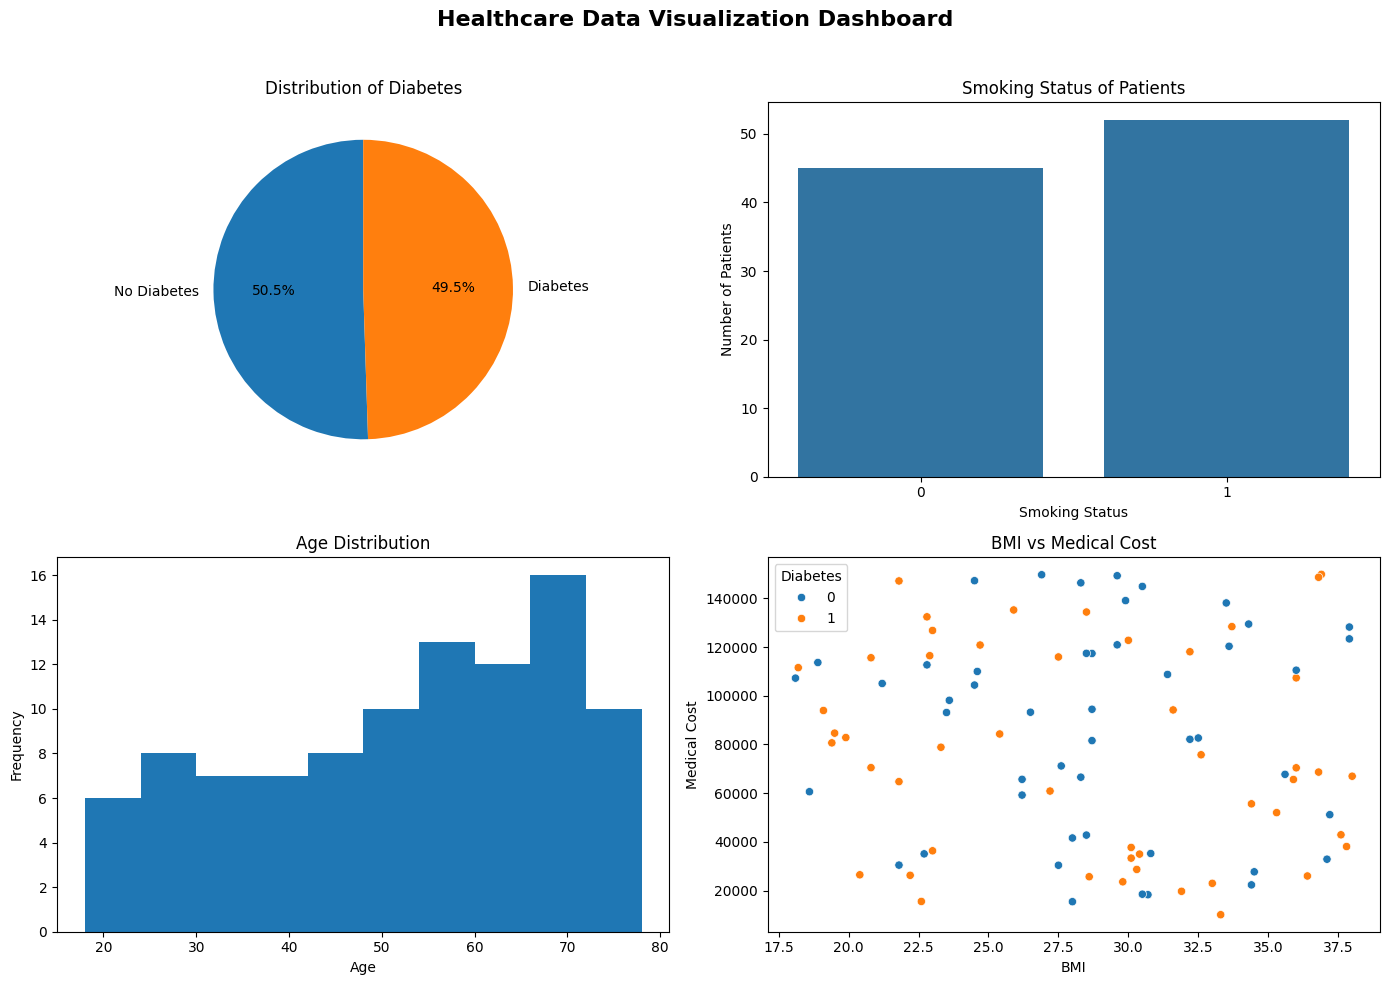



📌 Pie Chart Insight      : The pie chart shows the percentage distribution of diabetic and non-diabetic patients.
📌 Bar Chart Insight      : The bar chart compares the number of smokers and non-smokers in the dataset.
📌 Histogram Insight      : The histogram illustrates the distribution of patients across different age groups.
📌 Scatter Plot Insight   : The scatter plot indicates that patients with higher BMI generally tend to have higher medical costs.

📋 FINAL BUSINESS INSIGHTS

✅ The dataset was successfully cleaned by handling missing values and removing duplicate records.

✅ Categorical variables were encoded to prepare the dataset for Machine Learning.

✅ Summary statistics provided valuable information about patient demographics and healthcare costs.

✅ The pie chart highlighted the distribution of diabetic and non-diabetic patients.

✅ The bar chart showed the comparison between smokers and non-smokers.

✅ The histogram revealed the age distribution of patients.

✅ The scatte

In [23]:
# ================================================
#      BUSINESS INSIGHTS & VISUALIZATION REPORT
# ================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("="*75)
print("        HEALTHCARE DATASET - BUSINESS INSIGHTS REPORT")
print("="*75)

# =====================================================
# 1. SUMMARY STATISTICS
# =====================================================

print("\n📊 SUMMARY STATISTICS")
print("-"*75)


print("\nOverall Dataset Summary")
print("-"*75)
print("\n")
print(f"👥 Total Patients            : {len(df)}")
print(f"👨 Male Patients             : {(df['Gender']==0).sum()}")
print(f"👩 Female Patients           : {(df['Gender']==1).sum()}")
print(f"🩺 Patients with Diabetes    : {(df['Diabetes']==1).sum()}")
print(f"💚 Patients without Diabetes : {(df['Diabetes']==0).sum()}")
print(f"🚬 Smokers                  : {(df['Smoking_Status']==1).sum()}")
print(f"🚭 Non-Smokers              : {(df['Smoking_Status']==0).sum()}")
print(f"📅 Average Hospital Visits   : {df['Hospital_Visits'].mean():.2f}")
print(f"📈 Average BMI               : {df['BMI'].mean():.2f}")
print(f"💰 Average Medical Cost      : ₹{df['Medical_Cost'].mean():,.2f}")
print("\n")

# =====================================================
# 2. CHARTS DASHBOARD (2 × 2 GRID)
# =====================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --------------------------
# PIE CHART
# --------------------------

df["Diabetes"].value_counts().plot(
    kind="pie",
    labels=["No Diabetes", "Diabetes"],
    autopct="%1.1f%%",
    startangle=90,
    ax=axes[0,0]
)


axes[0,0].set_title("Distribution of Diabetes")
axes[0,0].set_ylabel("")

# --------------------------
# BAR CHART
# --------------------------

sns.countplot(
    data=df,
    x="Smoking_Status",
    ax=axes[0,1]
)

axes[0,1].set_title("Smoking Status of Patients")
axes[0,1].set_xlabel("Smoking Status")
axes[0,1].set_ylabel("Number of Patients")

# --------------------------
# HISTOGRAM
# --------------------------

axes[1,0].hist(df["Age"], bins=10)

axes[1,0].set_title("Age Distribution")
axes[1,0].set_xlabel("Age")
axes[1,0].set_ylabel("Frequency")

# --------------------------
# SCATTER PLOT
# --------------------------

sns.scatterplot(
    data=df,
    x="BMI",
    y="Medical_Cost",
    hue="Diabetes",
    ax=axes[1,1]
)

axes[1,1].set_title("BMI vs Medical Cost")
axes[1,1].set_xlabel("BMI")
axes[1,1].set_ylabel("Medical Cost")

plt.suptitle("Healthcare Data Visualization Dashboard", fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

# --------------------------
# CHART INSIGHTS
# --------------------------

print("\n")
print("📌 Pie Chart Insight      : The pie chart shows the percentage distribution of diabetic and non-diabetic patients.")
print("📌 Bar Chart Insight      : The bar chart compares the number of smokers and non-smokers in the dataset.")
print("📌 Histogram Insight      : The histogram illustrates the distribution of patients across different age groups.")
print("📌 Scatter Plot Insight   : The scatter plot indicates that patients with higher BMI generally tend to have higher medical costs.\n")

# =====================================================
# 6. FINAL BUSINESS INSIGHTS
# =====================================================

print("="*75)
print("📋 FINAL BUSINESS INSIGHTS")
print("="*75)

print("""
✅ The dataset was successfully cleaned by handling missing values and removing duplicate records.

✅ Categorical variables were encoded to prepare the dataset for Machine Learning.

✅ Summary statistics provided valuable information about patient demographics and healthcare costs.

✅ The pie chart highlighted the distribution of diabetic and non-diabetic patients.

✅ The bar chart showed the comparison between smokers and non-smokers.

✅ The histogram revealed the age distribution of patients.

✅ The scatter plot suggested a positive relationship between BMI and Medical Cost.

✅ The processed dataset is clean, consistent, and ready for further AI and Machine Learning model development.
""")

print("="*75)
print("🎉 Exploratory Data Analysis & Business Insights Completed Successfully")
print("="*75)


The dataset was successfully analyzed using EDA techniques. Summary statistics and visualizations provided meaningful insights into the data, and the cleaned dataset is now ready for further Machine Learning and AI model development.


#**6**. **Feature Scaling**

**Feature Scaling** : Normalize numerical features using Min-Max Scaling so that all values fall within the range of 0 to 1

Feature Scaling is the process of converting numerical values to a common scale so that all features have a similar range this helps Machine Learning algorithms process the data more effectively and prevents features with larger values from dominating those with smaller values

In this task, Min-Max Scaling is used to normalize the selected numerical columns by converting their values to a range between 0 and 1, where 0 represents the minimum value and 1 represents the maximum value this improves data consistency and prepares the dataset for Machine Learning models

Example:

Before Scaling (Age) : 20,40,60 ;	After Scaling (Age) : 0.00,0.50,1.00


In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["Age", "Blood_Pressure", "Heart_Rate", "BMI", "Hospital_Visits", "Medical_Cost"]] = scaler.fit_transform(
    df[["Age", "Blood_Pressure", "Heart_Rate", "BMI", "Hospital_Visits", "Medical_Cost"]]
)

In [25]:
df

,Patient_ID,Patient_Name,Age,Gender,Blood_Pressure,Heart_Rate,BMI,Diabetes,Smoking_Status,Hospital_Visits,Medical_Cost
0,P001,Vihaan Sharma,0.783333,1,0.426471,0.28,0.135678,1,1,0.750000,0.754988
1,P002,Vivaan Sharma,0.083333,0,0.397059,0.64,0.597990,1,0,0.250000,0.806177
2,P003,Karan Singh,0.850000,0,0.264706,0.88,0.422111,0,1,0.250000,0.594915
3,P004,Vihaan Verma,0.400000,0,0.632353,0.44,0.603015,1,0,0.666667,0.197637
4,P005,Sneha Verma,0.583333,1,0.647059,0.72,0.185930,1,1,0.833333,0.391002
...,...,...,...,...,...,...,...,...,...,...,...
92,P093,Sneha Mehta,0.666667,1,0.985294,0.04,0.613065,1,0,0.250000,0.133015
93,P094,Kavya Verma,0.800000,0,0.794118,0.20,0.693467,1,1,0.416667,0.068744
94,P095,Ishita Mehta,0.383333,1,0.235294,0.30,0.527638,1,1,0.166667,0.111610
98,P099,Karan Singh,0.733333,1,0.000000,0.84,0.391960,1,1,0.750000,0.895324


Count the number of patients in each diabetes category (Yes 1 /No 0 )

In [26]:
df["Diabetes"].value_counts()

,count
Diabetes,
1,49
0,48



#**7. Outlier Detection**

: Outlier Detection is the process of identifying unusual or extreme values in a dataset that differ significantly from the rest of the data.



Use a box plot to identify outliers in the Medical_Cost column : A box plot is used to detect outliers by identifying data points that lie outside the whiskers of the plot.

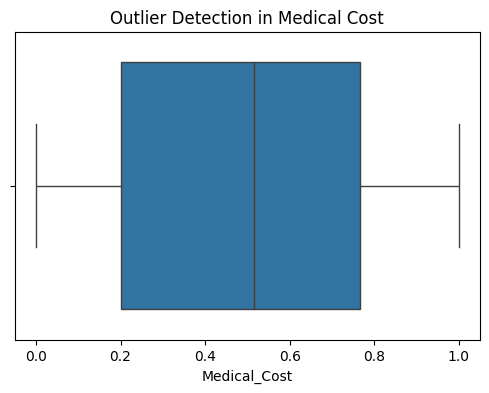

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Medical_Cost"])
plt.title("Outlier Detection in Medical Cost")
plt.show()

The box plot was used to identify outliers in the Medical_Cost column. Any values appearing as individual points outside the whiskers are considered outliers. These values may represent unusually high or low medical costs, data entry errors, or exceptional cases identifying these outliers helps improve data quality and ensures more reliable analysis before using the dataset for Machine Learning.